# Expected Goals Analysis in European Football

---

## 1. Introduction

Expected goals (xG) has become one of the most widely used metrics in modern football analytics because it helps separate underlying performance from match-level randomness. Since football is a low-scoring sport, final results are often influenced by short-term variance, finishing efficiency, goalkeeping performance, or isolated match events. In this context, xG-based metrics provide a more stable descriptive framework for evaluating team performance.

This notebook presents a **descriptive analysis** of expected goals and related team-level performance indicators across European football leagues. The goal is not to build a predictive model, but to examine how xG-based metrics can be used to compare leagues, identify long-term offensive and defensive overperformance, and describe structural differences between teams.

The analysis is organized into three main parts. First, it compares actual and expected goals across leagues and seasons. Second, it evaluates long-term efficiency through offensive and defensive ratios. Third, it focuses on a case study of the Premier League 2015/16 season, where Leicester City provides an analytically interesting example of a team that substantially outperformed conventional expectations.

In the final part of the notebook, clustering methods are used to explore structural team profiles based on offensive, defensive, and tactical indicators.

---

## 2. Dataset and Analytical Scope

### 2.1 Data Source

The analysis is based on a publicly available football dataset containing expected-goals-related team statistics for European leagues. The data are derived from Understat-based match and season summaries and are distributed in tabular form, where each row represents one team in a given league and season.

---

### 2.2 Main Variables

The dataset includes both conventional performance indicators and advanced expected metrics. The main variables used in this notebook are:

- `league` – league name  
- `season_year` – season identifier  
- `team` – team name  
- `matches`, `wins`, `draws`, `loses` – match outcomes  
- `scored`, `missed`, `pts` – goals scored, goals conceded, and points  
- `xG`, `xGA` – expected goals for and expected goals against  
- `xG_diff` – difference between actual and expected goals  
- `xpts`, `xpts_diff` – expected points and the difference from actual points  
- `ppda_coef`, `oppda_coef` – pressing-related indicators  
- `deep`, `deep_allowed` – entries into dangerous attacking zones and entries allowed to opponents

---

### 2.3 Scope of the Analysis

The full dataset covers six leagues and seasons between 2014 and 2019. However, the main analysis in this notebook focuses on the **top five European leagues**:

- Premier League
- La Liga
- Bundesliga
- Serie A
- Ligue 1

This restriction improves comparability across competitions and follows the analytical scope used in the thesis.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from src.config import configure_pandas, configure_plots, TOP5_LEAGUES
from src.data_prep import (
    load_dataset,
    filter_top5_leagues,
    get_dataset_overview,
    get_missing_values_table,
)
from src.metrics import (
    get_league_summary,
    get_league_season_summary,
    teams_present_in_all_seasons,
    compute_team_ratios,
    get_top_offensive_teams,
    get_top_defensive_teams,
    filter_league_season,
)
from src.plotting import (
    plot_league_comparison,
    plot_league_trends,
    plot_identity_scatter,
    plot_quadrant_scatter,
)
from src.clustering import (
    run_dbscan,
    plot_cluster_scatter,
    run_hierarchical_clustering,
    plot_dendrogram,
    summarize_clusters,
    get_cluster_members,
)

configure_pandas()
configure_plots()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---

## 3. Data Loading and Preprocessing

This section loads the dataset, inspects its structure, and applies basic preprocessing steps required for the subsequent analysis. The main goal is to create a clean analytical dataset with consistent column names, correct data types, and a restricted league scope focused on the top five European leagues.

---

## 3.1 Load the Dataset

In [2]:
df = load_dataset("Data/understat.csv", top5_only=False)
df_top5 = filter_top5_leagues(df)
display(df_top5.head())

,league,season_year,position,team,matches,wins,draws,loses,scored,missed,pts,xg,xg_diff,npxg,xga,xga_diff,npxga,npxgd,ppda_coef,oppda_coef,deep,deep_allowed,xpts,xpts_diff
0,Bundesliga,2014,5,Augsburg,34,15,4,15,43,43,49,43.91,0.91,37.72,46.66,3.66,43.63,-5.91,7.63,10.40,134,221,45.50,-3.50
1,Bundesliga,2014,4,Bayer Leverkusen,34,17,10,7,62,37,61,49.16,-12.84,48.40,34.72,-2.28,30.17,18.22,5.69,7.35,246,108,55.34,-5.66
2,Bundesliga,2014,1,Bayern Munich,34,25,4,5,80,18,79,66.21,-13.79,61.66,21.94,3.94,20.42,41.24,5.76,25.02,388,83,73.61,-5.39
3,Bundesliga,2014,7,Borussia Dortmund,34,13,7,14,47,42,46,53.86,6.86,51.59,33.40,-8.60,31.88,19.71,7.62,12.66,292,112,58.08,12.08
4,Bundesliga,2014,3,Borussia M.Gladbach,34,19,9,6,53,26,66,51.74,-1.26,49.47,36.34,10.34,33.31,16.16,12.75,12.78,221,198,57.01,-8.99


---

### 3.2 Initial Data Inspection

After loading and cleaning the dataset, the next step is to verify its structure, league coverage, seasonal coverage, and the presence of missing values. This helps confirm that the analytical dataset is suitable for the subsequent descriptive analysis.

In [3]:
overview_dict = get_dataset_overview(df_top5).copy()

if "columns" in overview_dict:
    overview_dict["columns"] = ", ".join(overview_dict["columns"])

overview = pd.Series(overview_dict, name="value").to_frame()
display(overview)

print("Column names:")
display(pd.DataFrame({"column": df_top5.columns}))

print("Data types:")
display(df_top5.dtypes.to_frame(name="dtype"))

print("Leagues included:")
display(df_top5["league"].value_counts().sort_index())

print("Seasons included:")
display(df_top5["season_year"].value_counts().sort_index())

print("Teams per league and season:")
team_counts = (
    df_top5.groupby(["league", "season_year"])["team"]
    .nunique()
    .reset_index(name="n_teams")
)
display(team_counts)

,value
shape,"(588, 24)"
n_duplicates,0
columns,"league, season_year, position, team, matches, ..."
n_leagues,5
n_seasons,6
n_teams,143


Column names:


,column
0,league
1,season_year
2,position
3,team
4,matches
5,wins
6,draws
7,loses
8,scored
9,missed


Data types:


,dtype
league,object
season_year,int64
position,int64
team,object
matches,int64
wins,int64
draws,int64
loses,int64
scored,int64
missed,int64


...

league
Bundesliga    108
EPL           120
La Liga       120
Ligue 1       120
Serie A       120
Name: count, dtype: int64

Seasons included:


season_year
2014    98
2015    98
2016    98
2017    98
2018    98
2019    98
Name: count, dtype: int64

Teams per league and season:


,league,season_year,n_teams
0,Bundesliga,2014,18
1,Bundesliga,2015,18
2,Bundesliga,2016,18
3,Bundesliga,2017,18
4,Bundesliga,2018,18
5,Bundesliga,2019,18
6,EPL,2014,20
7,EPL,2015,20
8,EPL,2016,20
9,EPL,2017,20


---

### 3.3 Missing Values and Data Quality

The table below reports missing values in the analytical dataset. Since the selected variables do not contain missing observations, no additional imputation or row-level filtering is required at this stage.

In [4]:
missing_table = get_missing_values_table(df_top5)
display(missing_table)

,missing_count,missing_pct
league,0,0.00
season_year,0,0.00
position,0,0.00
team,0,0.00
matches,0,0.00
wins,0,0.00
draws,0,0.00
loses,0,0.00
scored,0,0.00
missed,0,0.00


### 3.4 Preprocessing Summary

The dataset has now been loaded, cleaned, and restricted to the top five European leagues. Column names were standardized, league labels were harmonized, and the analytical sample was checked for missing values and structural consistency.

The resulting dataset is ready for league-level comparisons, ratio-based performance analysis, and the subsequent case study of the Premier League 2015/16 season.

---

## 4. League-Level Comparison of xG and Goals

This section compares expected goals and actual goals across the top five European leagues. The aim is to evaluate whether xG and real scoring output are broadly aligned at the aggregate level and whether individual leagues show different offensive trends over time.

---

### 4.1 Average xG and Goals by League

The first comparison focuses on the average number of expected goals and actual goals scored across leagues over the observed period. If xG is well calibrated at the league level, both quantities should be relatively close.

In [5]:
league_summary = get_league_summary(df_top5)
display(league_summary)

,league,avg_xg,avg_goals
0,Serie A,51.03,52.49
1,EPL,50.76,51.58
2,La Liga,50.59,50.99
3,Bundesliga,48.70,49.96
4,Ligue 1,45.14,46.75


> The comparison provides an aggregate view of league-level scoring environments. Small deviations between expected and actual goals may reflect differences in finishing efficiency, tactical style, or general league-specific match dynamics.

---

### 4.2 Seasonal Development of xG and Goals

To complement the aggregate league comparison, the following analysis examines how average expected goals and actual goals evolved over time within individual leagues.

In [7]:
league_season_summary = get_league_season_summary(df_top5)
display(league_season_summary.head(15))

,league,season_year,avg_xg,avg_goals
0,Bundesliga,2014,44.61,46.83
1,Bundesliga,2015,48.02,48.11
2,Bundesliga,2016,46.82,48.72
3,Bundesliga,2017,45.43,47.50
4,Bundesliga,2018,54.14,54.06
5,Bundesliga,2019,53.18,54.56
6,EPL,2014,48.33,48.75
7,EPL,2015,49.05,51.30
8,EPL,2016,49.18,53.20
9,EPL,2017,49.60,50.90


---

### 4.2.1 Bundesliga

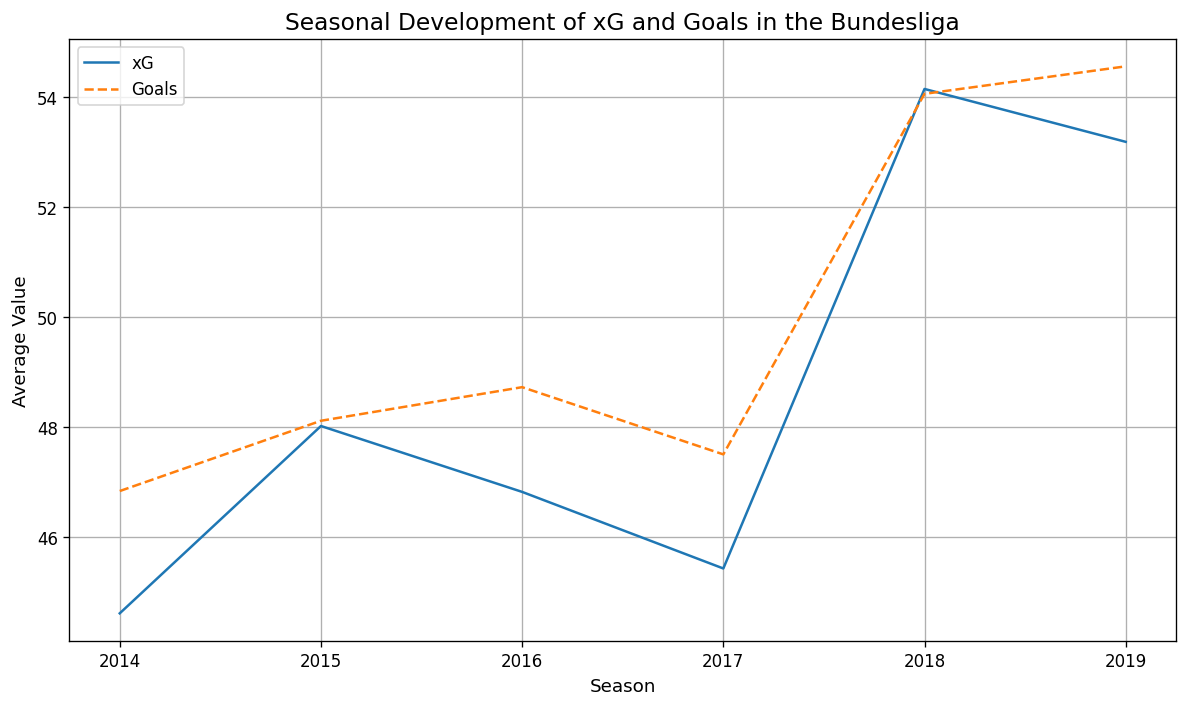

In [8]:
plot_league_trends(
    league_season_summary,
    league="Bundesliga",
    title="Seasonal Development of xG and Goals in the Bundesliga"
)

---

### 4.2.2 Ligue 1

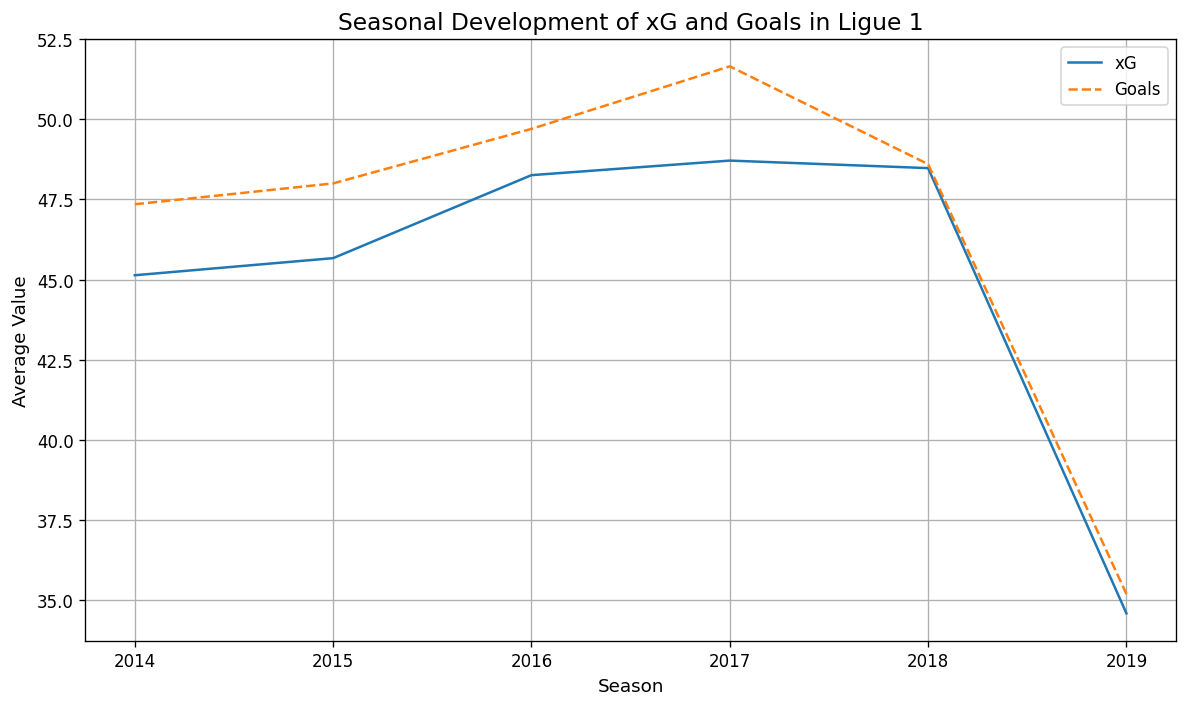

In [9]:
plot_league_trends(
    league_season_summary,
    league="Ligue 1",
    title="Seasonal Development of xG and Goals in Ligue 1"
)

---

### 4.2.3 La Liga

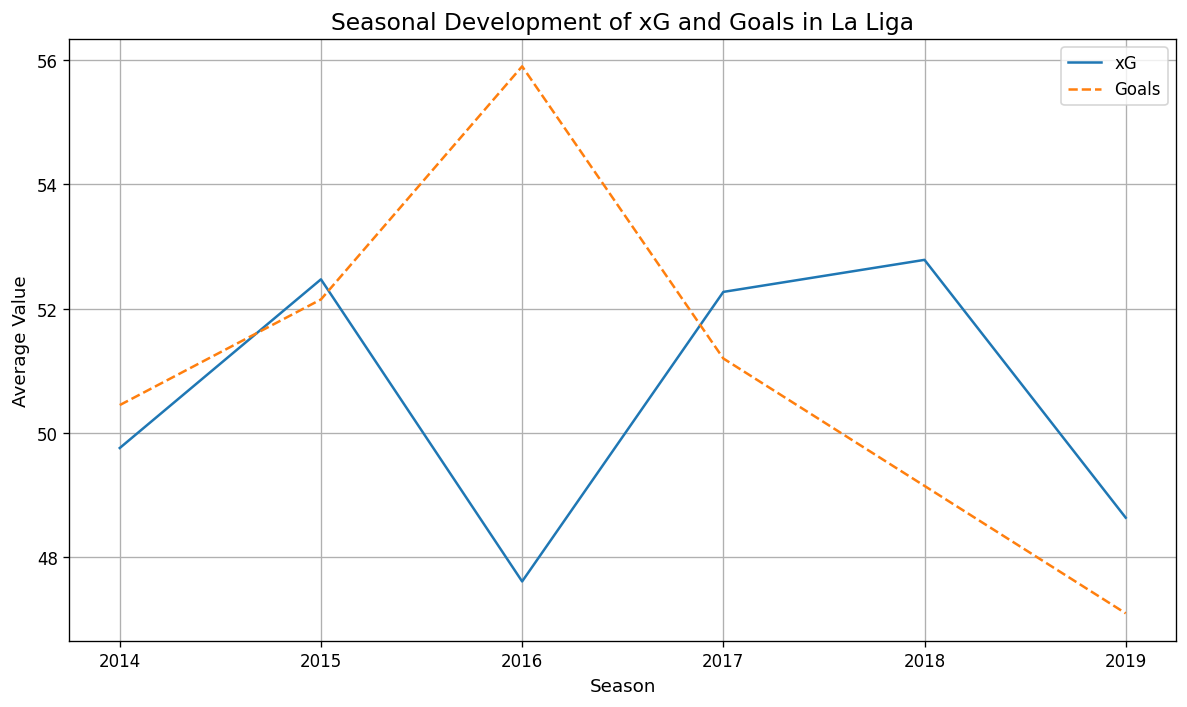

In [11]:
plot_league_trends(
    league_season_summary,
    league="La Liga",
    title="Seasonal Development of xG and Goals in La Liga"
)

> The time-series comparison helps reveal whether leagues became more attacking, more defensively balanced, or broadly stable over the observed period. It also highlights league-specific patterns that may not be visible from aggregate averages alone.

---

## 5. Long-Term Overperformance and Underperformance

This section evaluates long-term team efficiency by comparing actual outcomes with expected metrics. The analysis focuses on offensive and defensive ratios, which provide a compact way to quantify whether teams systematically overperform or underperform relative to xG-based expectations.

---

### 5.1 Offensive and Defensive Ratios

The offensive ratio is defined as:

$$
\text{Offensive Ratio} = \frac{\sum\text{Goals Scored}}{\sum\text{xG}}
$$

Values above 1 indicate that a team scored more goals than expected based on shot quality.

The defensive ratio is defined as:

$$
\text{Defensive Ratio} = \frac{\sum\text{Goals Conceded}}{\sum\text{xGA}}
$$

Values below 1 indicate that a team conceded fewer goals than expected based on the quality of chances allowed.

--- 

### 5.2 Team Filtering for Long-Term Comparison

To obtain more stable long-term comparisons, only teams present in all observed seasons are retained. This excludes clubs that were relegated or promoted during the period.

In [12]:
stable_teams = teams_present_in_all_seasons(df_top5)

print("Filtered dataset shape:", stable_teams.shape)
print("Number of teams present in all seasons:", stable_teams["team"].nunique())

Filtered dataset shape: (354, 24)
Number of teams present in all seasons: 59


In [16]:
team_ratios = compute_team_ratios(stable_teams)

--- 

### 5.3 Top Offensive Overperformers

In [17]:
top_offensive = get_top_offensive_teams(team_ratios, n=5).copy()
top_offensive["rank"] = range(1, len(top_offensive) + 1)

top_offensive_display = (
    top_offensive[["team", "xg", "goals_scored", "offensive_ratio", "rank"]]
    .rename(columns={
        "team": "Team",
        "xg": "xG",
        "goals_scored": "Goals",
        "offensive_ratio": "Offensive Ratio",
        "rank": "Rank"
    })
)

display(top_offensive_display)

,Team,xG,Goals,Offensive Ratio,Rank
0,Juventus,388.33,456,1.17,1
1,Werder Bremen,261.40,298,1.14,2
2,Tottenham,365.55,415,1.14,3
3,Lyon,371.22,418,1.13,4
4,Real Sociedad,282.27,315,1.12,5


> Teams at the top of this ranking scored systematically more goals than expected over the full observed period. Such results may indicate strong finishing quality, tactical efficiency, or persistent structural attacking advantages.

--- 

### 5.4 Top Defensive Overperformers

In [18]:
top_defensive = get_top_defensive_teams(team_ratios, n=5).copy()
top_defensive["rank"] = range(1, len(top_defensive) + 1)

top_defensive_display = (
    top_defensive[["team", "xga", "goals_conceded", "defensive_ratio", "rank"]]
    .rename(columns={
        "team": "Team",
        "xga": "xGA",
        "goals_conceded": "Goals Conceded",
        "defensive_ratio": "Defensive Ratio",
        "rank": "Rank"
    })
)

display(top_defensive_display)

,Team,xGA,Goals Conceded,Defensive Ratio,Rank
0,Atletico Madrid,196.64,152,0.77,1
1,Barcelona,218.16,190,0.87,2
2,Tottenham,267.04,236,0.88,3
3,Manchester United,245.02,219,0.89,4
4,Nice,284.92,255,0.89,5


> Teams with the lowest defensive ratios conceded substantially fewer goals than expected over the full period. This may reflect strong defensive organization, goalkeeper performance, or sustained structural defensive quality.

--- 

## 6. Premier League 2015/16: Leicester City Case Study

This section focuses on the 2015/16 Premier League season, which provides one of the most interesting case studies in modern football analytics. Leicester City won the league despite not being widely regarded as the most structurally dominant team in the competition.

The aim of this section is to examine Leicester's season through xG-based performance indicators and compare their actual outcomes with expected metrics. The analysis focuses on four perspectives:

1. points versus expected points,
2. goals scored versus expected goals,
3. goals conceded versus expected goals against,
4. the overall offensive-defensive team profile.

Together, these visualizations help determine whether Leicester's title-winning season was driven by attacking quality, defensive efficiency, exceptional conversion, or broader structural balance.

In [55]:
epl_2015 = filter_league_season(df_top5, league="EPL", season_year=2015)

leicester_team = [
    team for team in epl_2015["team"].unique()
    if "leicester" in team.lower()
]

print("Filtered dataset shape:", epl_2015.shape)
print("Highlighted team:", leicester_team)

Filtered dataset shape: (20, 24)
Highlighted team: ['Leicester']



---
### 6.1 Final League Table Context

Before turning to the expected-metrics analysis, it is useful to include the final Premier League table for the 2015/16 season. The following case study repeatedly refers to teams in relation to their final ranking, so the table provides an important descriptive reference point for the interpretation of Leicester City's title-winning season.

<p align="center">
  <img src="1516_epl.png" alt="Premier League 2015/16 final table" width="700">
</p>

<p align="center"><em>Final Premier League table in the 2015/16 season.</em></p>

--- 

### 6.2 Points vs Expected Points

The first comparison evaluates actual points against expected points (`xpts`). The identity line \( y = x \) represents teams whose actual point total exactly matches the level predicted by the quality of chances created and conceded.

Teams above the line overperformed relative to xPts, while teams below the line underperformed.

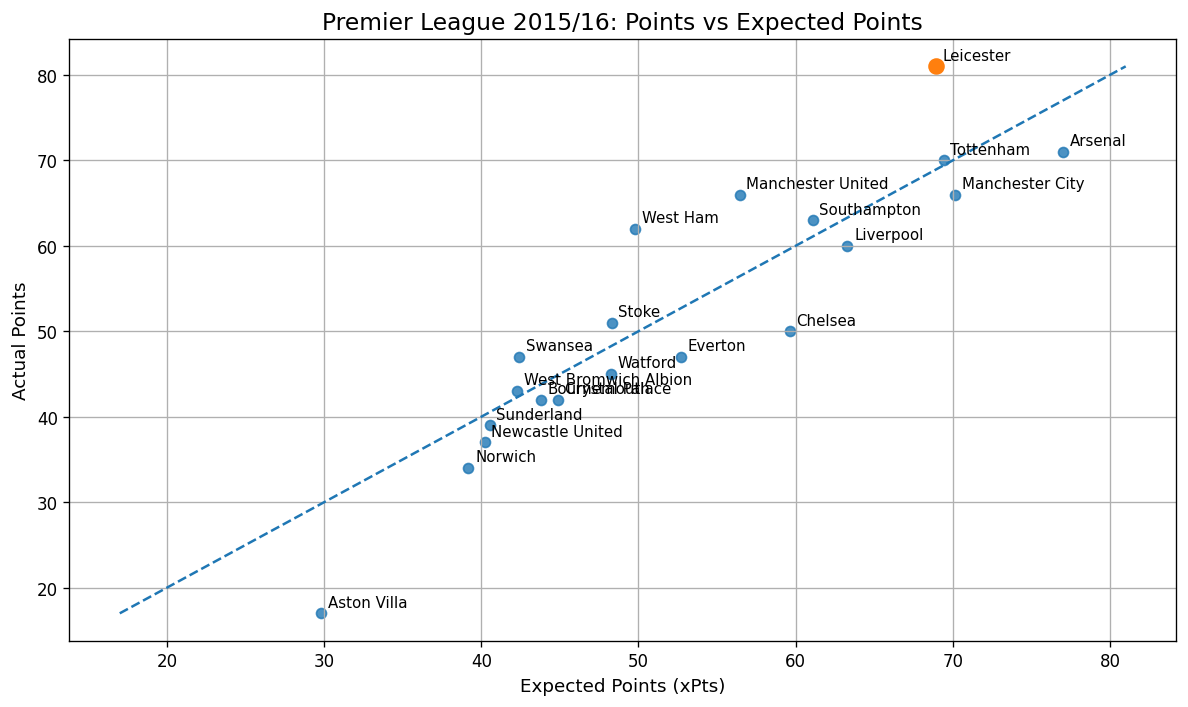

In [21]:
plot_identity_scatter(
    epl_2015,
    x="xpts",
    y="pts",
    label_col="team",
    highlight=leicester_team,
    title="Premier League 2015/16: Points vs Expected Points",
    xlabel="Expected Points (xPts)",
    ylabel="Actual Points",
    annotate=True,   # Change to False if the labels feel too crowded
)

> Leicester City is expected to appear clearly above the identity line, indicating that the team gained substantially more points than would be predicted by xG-based expectations alone. This makes Leicester the most analytically interesting outlier of the season.

### 6.3 Goals Scored vs Expected Goals

The second comparison examines attacking efficiency by relating actual goals scored to expected goals. The identity line again represents perfect alignment between chance quality and final goal output.

Teams above the line scored more than expected, while teams below the line converted their chances less efficiently.

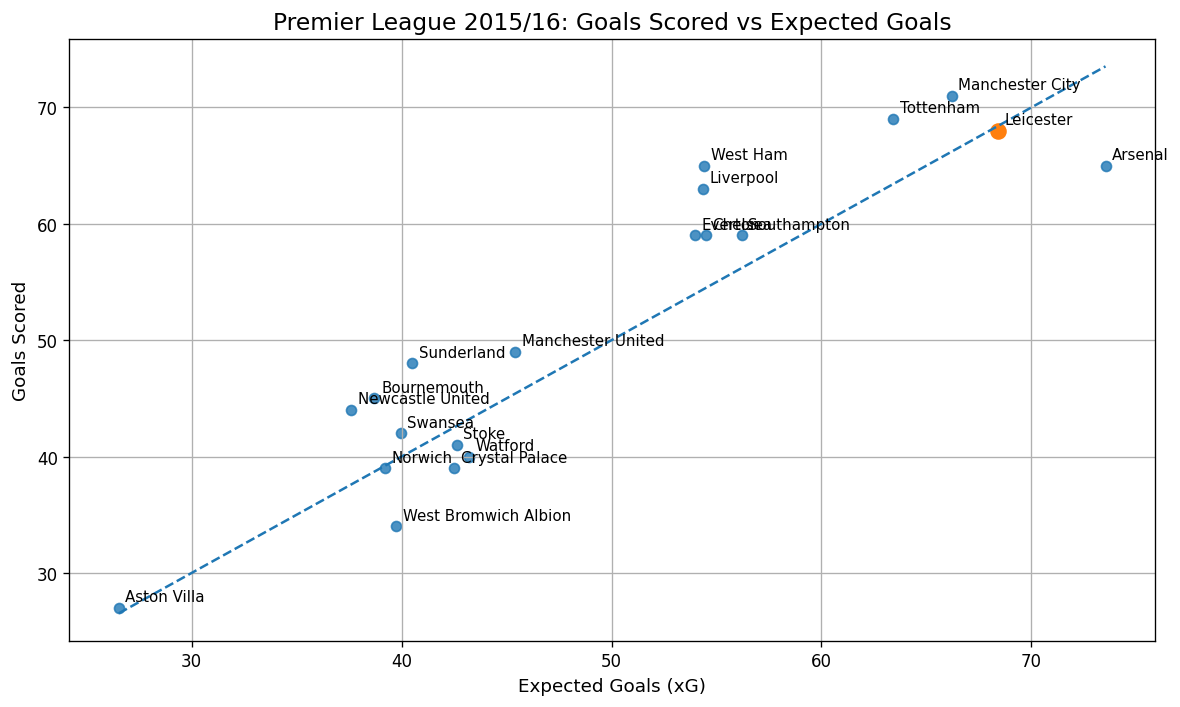

In [22]:
plot_identity_scatter(
    epl_2015,
    x="xg",
    y="scored",
    label_col="team",
    highlight=leicester_team,
    title="Premier League 2015/16: Goals Scored vs Expected Goals",
    xlabel="Expected Goals (xG)",
    ylabel="Goals Scored",
    annotate=True,
)

> This figure helps determine whether Leicester's season was primarily driven by attacking overperformance. If Leicester appears close to the identity line, their title run was not mainly a story of extreme attacking overconversion. If the club lies clearly above the line, finishing efficiency played a more substantial role.

---

### 6.4 Goals Conceded vs Expected Goals Against

The third comparison focuses on the defensive side of performance. Here, actual goals conceded are compared with expected goals against (`xGA`).

Teams below the identity line conceded fewer goals than expected and can therefore be interpreted as defensively efficient relative to the quality of chances they allowed.

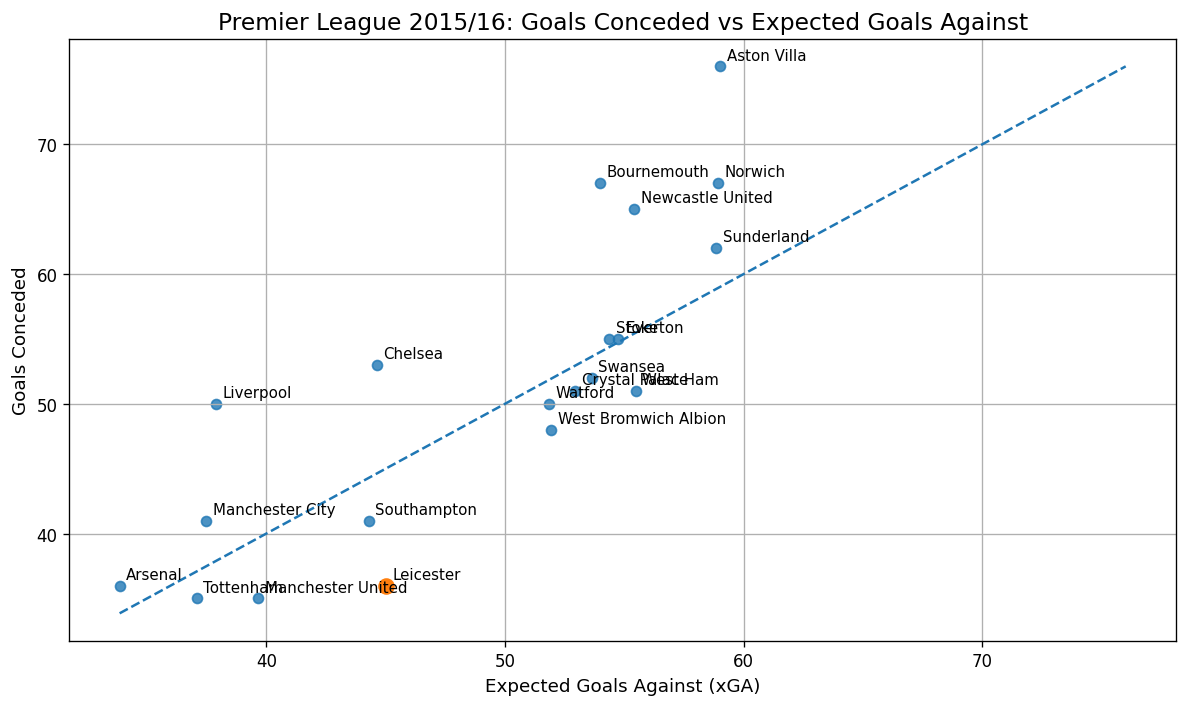

In [23]:
plot_identity_scatter(
    epl_2015,
    x="xga",
    y="missed",
    label_col="team",
    highlight=leicester_team,
    title="Premier League 2015/16: Goals Conceded vs Expected Goals Against",
    xlabel="Expected Goals Against (xGA)",
    ylabel="Goals Conceded",
    annotate=True,
)

> If Leicester appears meaningfully below the identity line, it suggests that one of the main drivers of the title-winning season was defensive efficiency rather than exceptional attacking overperformance. This would be consistent with the interpretation that Leicester combined solid structure with above-expected defensive outcomes.

---

### 6.5 Offensive-Defensive Team Profile

The final visualization combines both dimensions into a single offensive-defensive team profile. The horizontal axis represents attacking strength (`xG`), while the vertical axis represents defensive exposure (`xGA`).

Higher xG indicates stronger attacking production, whereas lower xGA indicates greater defensive stability. League-average reference lines divide the figure into broad structural team profiles.

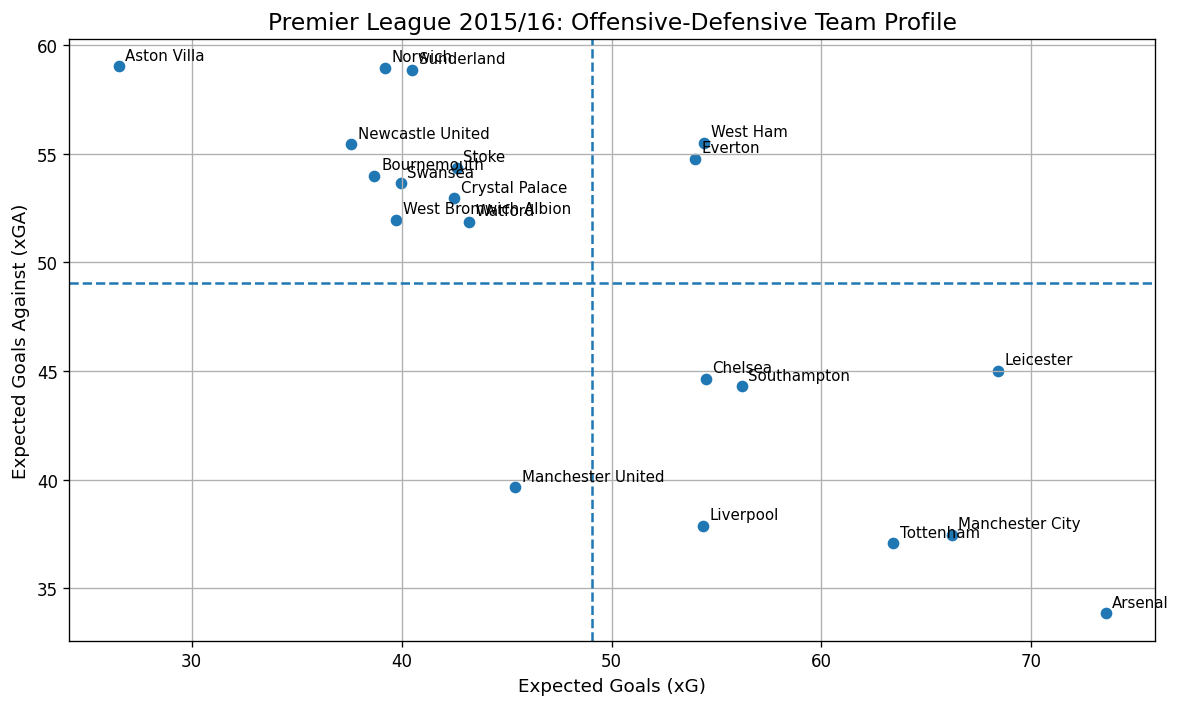

In [24]:
xg_mean = epl_2015["xg"].mean()
xga_mean = epl_2015["xga"].mean()

plot_quadrant_scatter(
    epl_2015,
    x="xg",
    y="xga",
    label_col="team",
    x_ref=xg_mean,
    y_ref=xga_mean,
    title="Premier League 2015/16: Offensive-Defensive Team Profile",
    xlabel="Expected Goals (xG)",
    ylabel="Expected Goals Against (xGA)",
    annotate=True,
)

This chart allows us to position Leicester within the broader competitive structure of the league.

- Teams in the **bottom-right quadrant** combine strong attacking output with solid defensive performance.
- Teams in the **top-left quadrant** are weak in both dimensions.
- Teams in the **top-right quadrant** are offensively strong but defensively vulnerable.
- Teams in the **bottom-left quadrant** are defensively solid but relatively limited going forward.

Leicester's location in this figure helps determine whether the title-winning season reflected full structural dominance or a more balanced profile supported by efficiency in key moments.

### 6.6 Section Summary

The Leicester case study provides a useful example of how xG-based metrics can add nuance to traditional league-table interpretation. Rather than relying only on points or goals, the comparison with expected metrics helps distinguish between structural team quality, short-term efficiency, and possible overperformance relative to underlying chance creation and prevention.

--- 

## 7. Structural Analysis of Team Styles

While the previous section focused on expected outcomes such as points, goals scored, and goals conceded, this part of the analysis examines deeper structural characteristics of team play.

Two groups of variables are considered. The first captures territorial control and attacking access to dangerous areas through the `deep` and `deep_allowed` metrics. The second captures pressing-related behaviour through `ppda_coef` and `oppda_coef`.

The goal is to determine whether Leicester City also appears structurally dominant in these dimensions, or whether the club's title-winning season was based more on efficiency than on clear territorial or pressing superiority.

---

### 7.1 Dangerous Territory Profile: Deep vs Deep Allowed

The first structural comparison focuses on entries into dangerous attacking zones (`deep`) and entries allowed to opponents (`deep_allowed`).

Higher values of `deep` indicate greater attacking presence in advanced dangerous areas, while lower values of `deep_allowed` indicate stronger defensive control of those same spaces. League-average reference lines help distinguish broad structural profiles across teams.

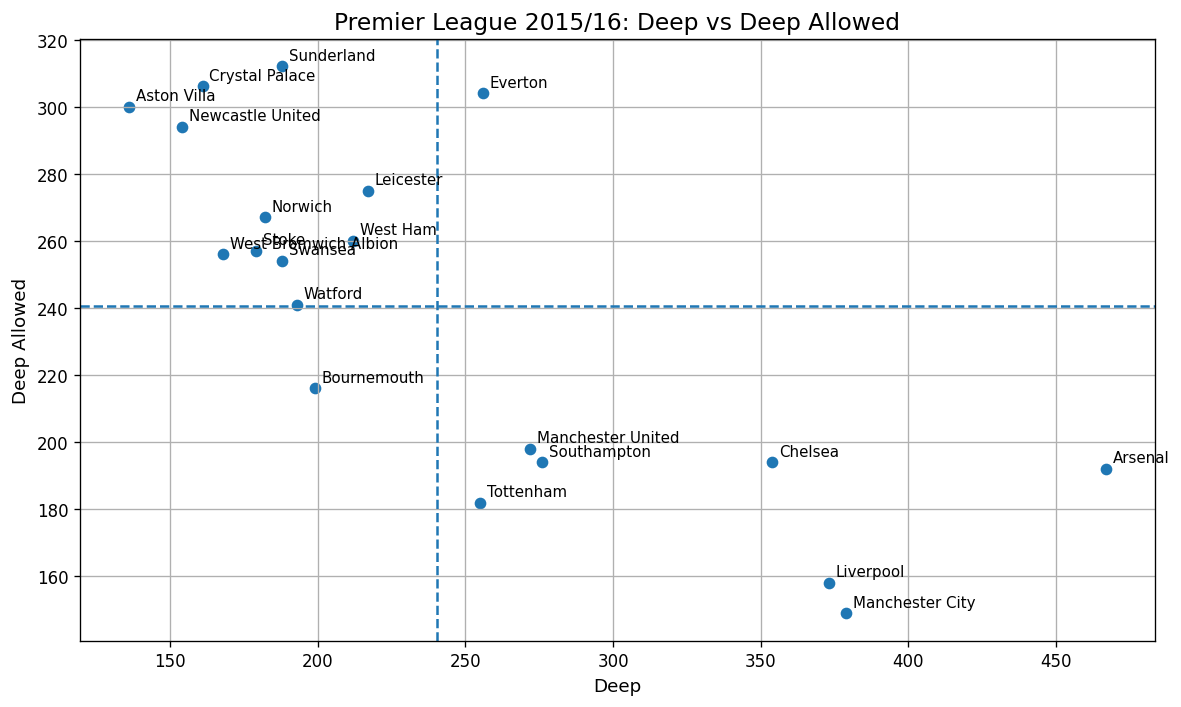

In [25]:
deep_mean = epl_2015["deep"].mean()
deep_allowed_mean = epl_2015["deep_allowed"].mean()

plot_quadrant_scatter(
    epl_2015,
    x="deep",
    y="deep_allowed",
    label_col="team",
    x_ref=deep_mean,
    y_ref=deep_allowed_mean,
    title="Premier League 2015/16: Deep vs Deep Allowed",
    xlabel="Deep",
    ylabel="Deep Allowed",
    annotate=True,
)

> This figure shows whether Leicester belonged to the most territorially dominant teams in the league or rather to a more balanced structural group. In particular, it helps evaluate whether the team combined strong attacking access to dangerous areas with effective defensive protection of those same zones.

---

### 7.2 DBSCAN Clustering of Dangerous Territory Profiles

To complement the visual inspection, the same two variables are used in a DBSCAN clustering procedure. This method identifies groups of structurally similar teams without requiring the number of clusters to be fixed in advance.

The aim is to determine whether Leicester belongs to a dominant territorial cluster, a more balanced middle group, or an outlier profile.

In [44]:
dbscan_deep = run_dbscan(
    epl_2015,
    feature_cols=["deep", "deep_allowed"],
    eps=0.6,
    min_samples=2,
    scale=True,
    label_cols=["team"],
)

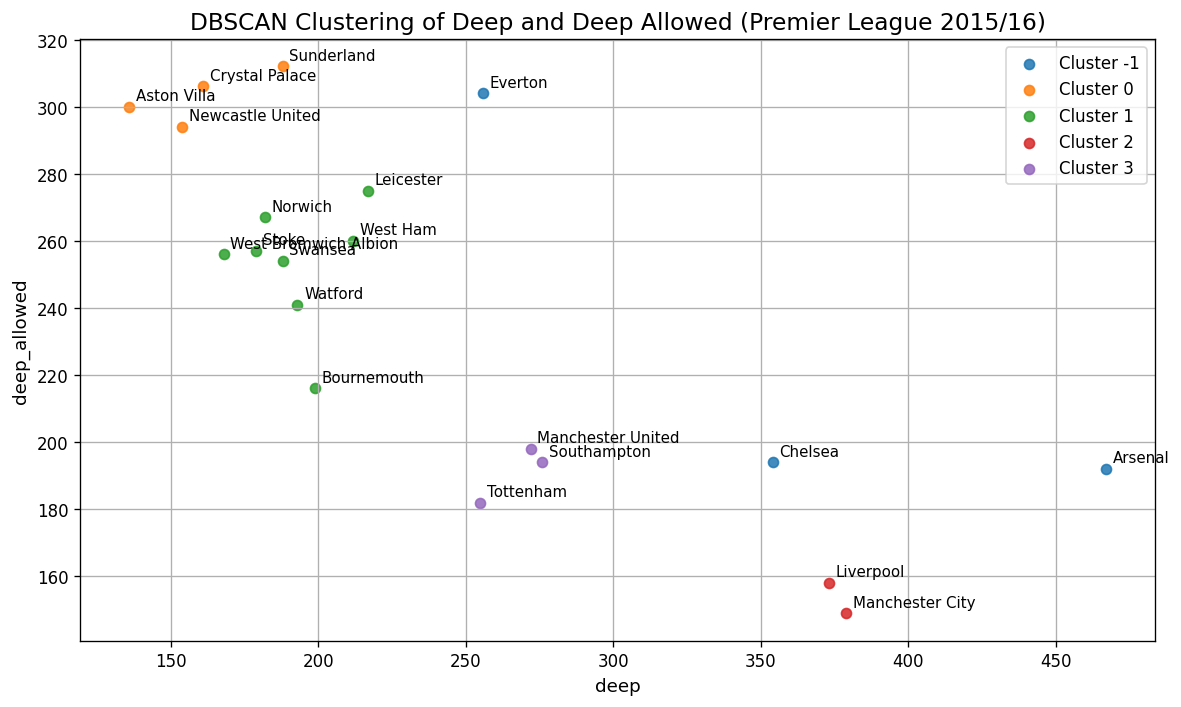

In [29]:
plot_cluster_scatter(
    dbscan_deep,
    x="deep",
    y="deep_allowed",
    cluster_col="dbscan_cluster",
    label_col="team",
    title="DBSCAN Clustering of Deep and Deep Allowed (Premier League 2015/16)",
    annotate=True,
)

In [30]:
deep_cluster_members = get_cluster_members(
    dbscan_deep,
    cluster_col="dbscan_cluster",
    label_col="team",
)

display(deep_cluster_members)

,dbscan_cluster,team
0,-1,Arsenal
1,-1,Chelsea
2,-1,Everton
3,0,Aston Villa
4,0,Crystal Palace
5,0,Newcastle United
6,0,Sunderland
7,1,Bournemouth
8,1,Leicester
9,1,Norwich


> The clustering result provides a more formal way to identify structurally similar teams. If Leicester is grouped with dominant teams, this would support the interpretation of structural superiority. If the club appears in a more average cluster, it would suggest that the title-winning season was not based primarily on territorial dominance.

---

### 7.3 Pressing Profile: PPDA vs OPPDA

The second structural comparison focuses on pressing behaviour. The variable `ppda_coef` reflects how many passes a team allows the opponent before making a defensive action in the attacking half, so lower values indicate more aggressive pressing.

The variable `oppda_coef` captures the same idea from the opposite perspective and reflects how much pressing pressure a team faces from opponents. Together, these variables provide a compact representation of team pressing style.

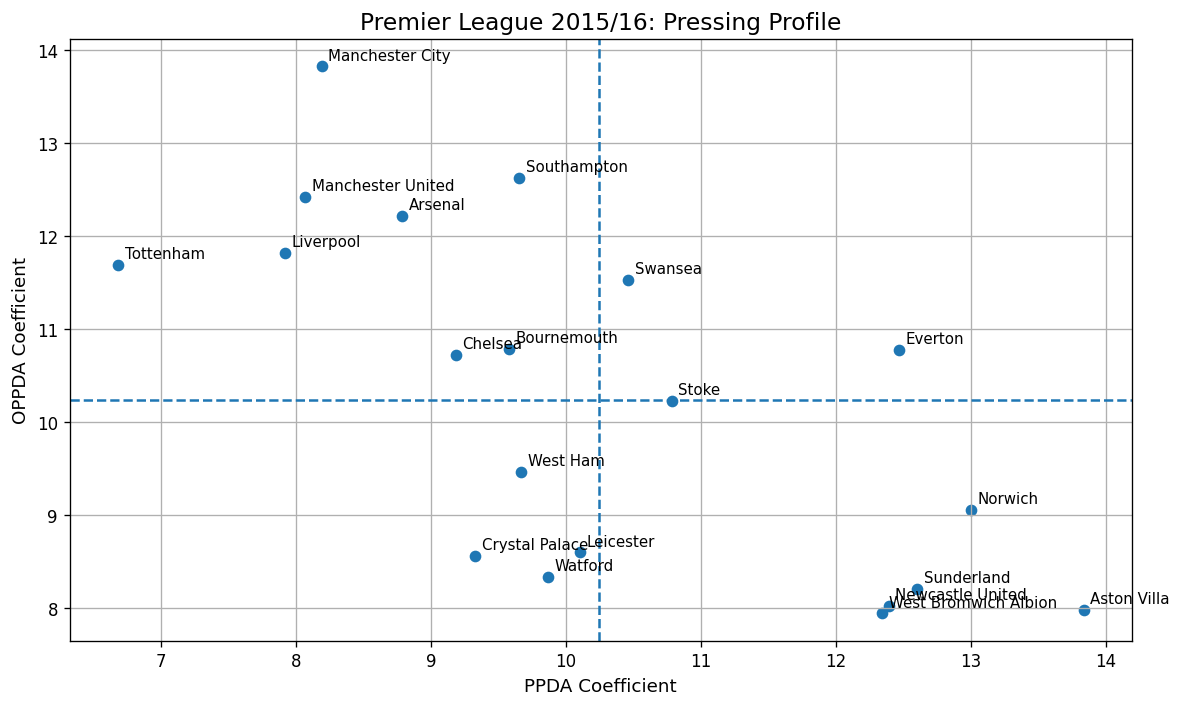

In [31]:
ppda_mean = epl_2015["ppda_coef"].mean()
oppda_mean = epl_2015["oppda_coef"].mean()

plot_quadrant_scatter(
    epl_2015,
    x="ppda_coef",
    y="oppda_coef",
    label_col="team",
    x_ref=ppda_mean,
    y_ref=oppda_mean,
    title="Premier League 2015/16: Pressing Profile",
    xlabel="PPDA Coefficient",
    ylabel="OPPDA Coefficient",
    annotate=True,
)

--- 

### 7.4 DBSCAN Clustering of Pressing Profiles

The same clustering procedure is now applied to the pressing-related variables. The goal is to identify broader structural groups of teams with similar pressing behaviour and to evaluate Leicester's position within that structure.

In [43]:
dbscan_pressing = run_dbscan(
    epl_2015,
    feature_cols=["ppda_coef", "oppda_coef"],
    eps=0.73,
    min_samples=3,
    scale=True,
    label_cols=["team"],
)

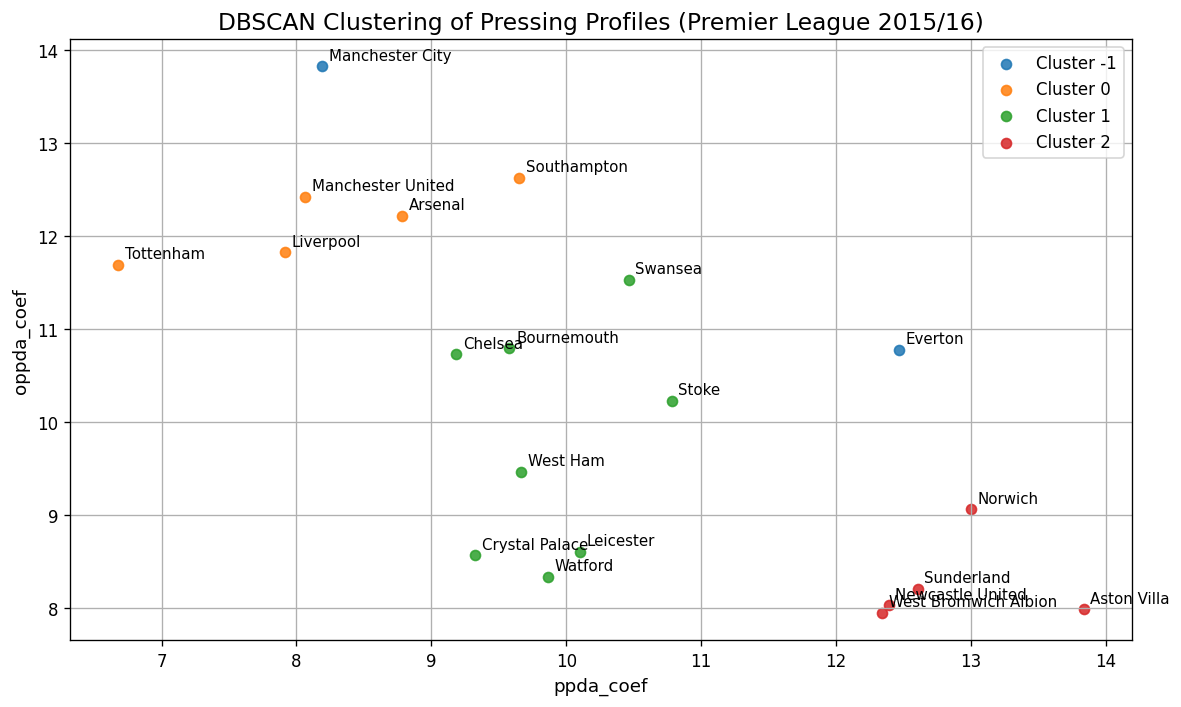

In [38]:
plot_cluster_scatter(
    dbscan_pressing,
    x="ppda_coef",
    y="oppda_coef",
    cluster_col="dbscan_cluster",
    label_col="team",
    title="DBSCAN Clustering of Pressing Profiles (Premier League 2015/16)",
    annotate=True,
)

In [42]:
pressing_cluster_members = get_cluster_members(
    dbscan_pressing,
    cluster_col="dbscan_cluster",
    label_col="team",
)

display(pressing_cluster_members)

,dbscan_cluster,team
0,-1,Everton
1,-1,Manchester City
2,0,Arsenal
3,0,Liverpool
4,0,Manchester United
5,0,Southampton
6,0,Tottenham
7,1,Bournemouth
8,1,Chelsea
9,1,Crystal Palace


> The pressing-based clustering provides additional evidence on whether Leicester's title-winning season was supported by a clearly distinct tactical identity or by a profile closer to the league average.

---

### 7.5 Section Summary

The structural analysis complements the xG-based evaluation by focusing on how teams controlled territory and applied defensive pressure. Together, the dangerous territory profile and the pressing profile provide a broader view of team style beyond goals and points alone.

For Leicester City, this section is especially important because it helps clarify whether the 2015/16 title was associated with clear structural dominance or with a more balanced profile combined with efficiency in key phases of play.

---

## 8. Hierarchical Clustering of Team Profiles

While the DBSCAN analysis focused on selected pairs of structural variables, this section extends the analysis to a broader multivariate team profile. Hierarchical clustering makes it possible to examine whether teams form natural groups when offensive production, defensive stability, efficiency, pressing intensity, and territorial control are considered jointly.

The goal is to identify structurally similar teams in the Premier League 2015/16 season and to determine how Leicester City compares with other clubs when several performance dimensions are combined in one analytical framework.

---

### 8.1 Selected Features

The clustering procedure is based on six variables that jointly capture offensive, defensive, and tactical aspects of team performance:

- `xg` – attacking production,
- `xga` – defensive exposure,
- `xg_diff` – difference between actual and expected goals,
- `xpts_diff` – difference between actual and expected points,
- `ppda_coef` – pressing intensity,
- `deep` – entries into dangerous attacking zones.

Together, these variables provide a compact representation of team style and performance structure.

In [45]:
hierarchical_features = ["xg", "xga", "xg_diff", "xpts_diff", "ppda_coef", "deep"]

display(
    epl_2015[["team"] + hierarchical_features]
    .sort_values("team")
    .reset_index(drop=True)
)

,team,xg,xga,xg_diff,xpts_diff,ppda_coef,deep
0,Arsenal,73.53,33.86,8.53,6.01,8.79,467
1,Aston Villa,26.53,59.01,-0.47,12.81,13.84,136
2,Bournemouth,38.71,53.97,-6.29,1.77,9.58,199
3,Chelsea,54.48,44.63,-4.52,9.62,9.18,354
4,Crystal Palace,42.51,52.94,3.51,2.89,9.33,161
5,Everton,53.98,54.75,-5.02,5.69,12.47,256
6,Leicester,68.42,45.02,0.42,-12.06,10.10,217
7,Liverpool,54.37,37.88,-8.63,3.29,7.92,373
8,Manchester City,66.20,37.47,-4.80,4.14,8.19,379
9,Manchester United,45.42,39.66,-3.58,-9.56,8.07,272


--- 

### 8.2 Feature Standardization

Because the selected variables are measured on different scales, they need to be standardized before clustering. This ensures that no single variable dominates the distance calculation purely because of its numerical range.

---

### 8.3 Hierarchical Clustering and Dendrogram

Hierarchical clustering is performed using Ward's linkage method. This approach merges teams in a way that minimizes the increase in within-cluster variance at each step, which makes it particularly suitable for identifying compact groups of structurally similar observations.

In [48]:
hier_df, linkage_matrix = run_hierarchical_clustering(
    epl_2015,
    feature_cols=hierarchical_features,
    n_clusters=4,
    method="ward",
    scale=True,
    label_cols=["team"],
)

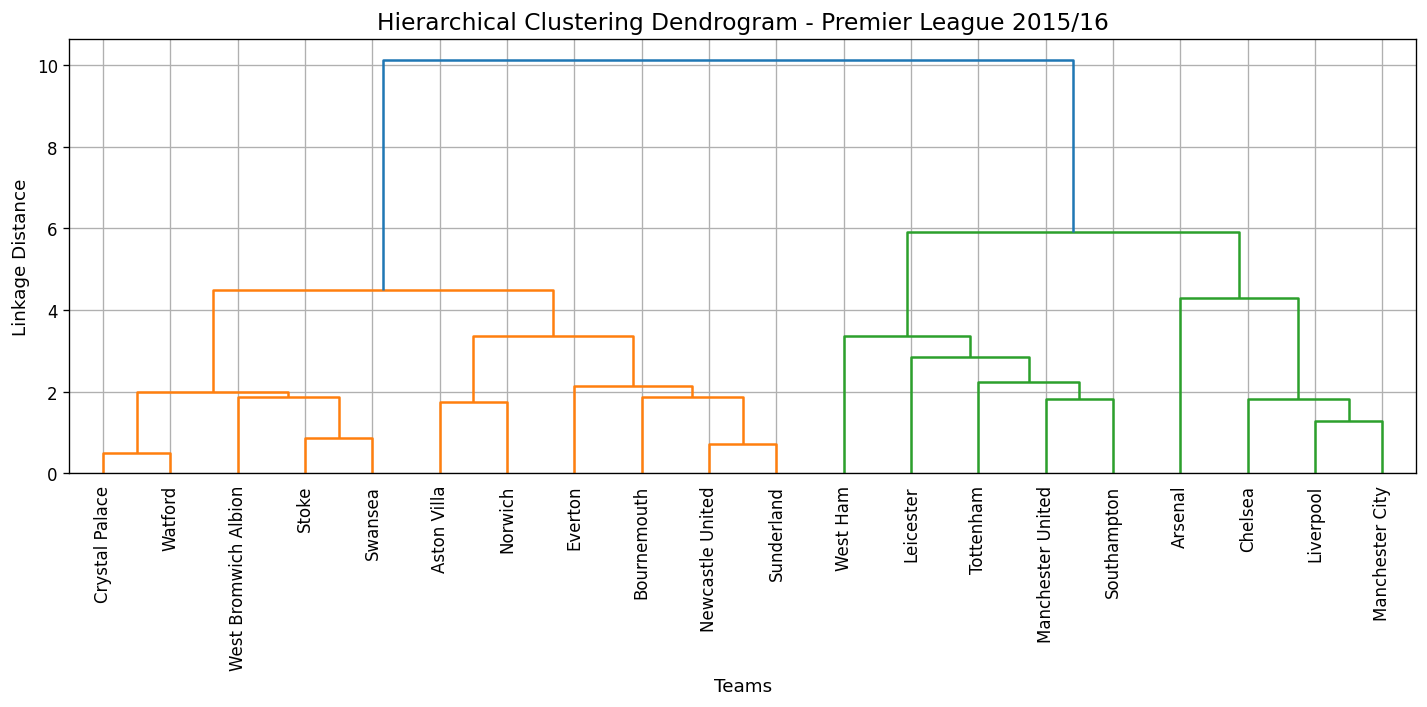

In [47]:
plot_dendrogram(
    linkage_matrix,
    labels=hier_df["team"].tolist(),
    title="Hierarchical Clustering Dendrogram - Premier League 2015/16"
)

> The dendrogram visualizes the similarity structure among teams and helps determine a reasonable number of clusters. In this notebook, the dendrogram is cut into four groups in order to obtain an interpretable classification of team profiles.

---

### 8.4 Cluster Assignment

The following table shows the cluster assignment for each team.

In [49]:
hier_cluster_members = get_cluster_members(
    hier_df,
    cluster_col="hier_cluster",
    label_col="team",
)

display(hier_cluster_members)

,hier_cluster,team
0,1,Crystal Palace
1,1,Stoke
2,1,Swansea
3,1,Watford
4,1,West Bromwich Albion
5,2,Aston Villa
6,2,Bournemouth
7,2,Everton
8,2,Newcastle United
9,2,Norwich


---

### 8.5 Cluster Summary Table

To interpret the resulting groups, the next table reports average values of the selected features within each cluster.

In [51]:
hier_cluster_summary = summarize_clusters(
    hier_df,
    cluster_col="hier_cluster",
    feature_cols=hierarchical_features,
    count_label="team",
)

display(hier_cluster_summary)

,hier_cluster,xg,xga,xg_diff,xpts_diff,ppda_coef,deep,n_observations
0,1,41.61,52.94,2.41,-0.37,10.55,177.80,5
1,2,39.42,56.82,-4.25,5.03,12.31,185.83,6
2,3,57.57,44.31,-4.43,-7.26,8.83,246.40,5
3,4,62.14,38.46,-2.36,5.76,8.52,393.25,4


---

### 8.6 Cluster Interpretation

The cluster summary can be used to distinguish broad structural team profiles within the league. In general terms, the four groups may be interpreted as follows:

- **dominant teams** with strong attacking production, good defensive control, and active pressing,
- **weaker or structurally limited teams** with lower xG, higher xGA, and weaker territorial presence,
- **balanced but efficient teams** that may not dominate structurally but still achieve strong outcomes,
- **intermediate or mixed-profile teams** that combine some strengths with clear limitations.

The exact interpretation depends on the observed cluster means and team membership.

In [52]:
leicester_cluster = hier_df.loc[
    hier_df["team"].str.lower().str.contains("leicester"),
    ["team", "hier_cluster"]
]

display(leicester_cluster)

,team,hier_cluster
6,Leicester,3


> A key question is whether Leicester City belongs to the cluster of structurally dominant teams or to a more balanced group. If Leicester is not grouped with the most dominant clubs, this supports the interpretation that the title-winning season was driven less by complete structural superiority and more by efficiency, defensive effectiveness, and an ability to outperform expectation-based metrics in decisive moments.

---

### 8.7 Section Summary

Hierarchical clustering provides a broader multivariate perspective on team profiles than the previous pairwise comparisons. By combining attacking output, defensive exposure, efficiency, pressing behaviour, and territorial presence, it becomes possible to identify groups of teams with similar overall structural characteristics.

For Leicester City, this analysis is particularly useful because it helps evaluate whether the 2015/16 title-winning campaign reflected dominant underlying structure or a more balanced profile supported by strong efficiency and favourable realization of key outcomes.

---



## 9. Key Findings

> ### Key Takeaways 

**1. xG and actual goals were closely aligned at the league level.**  
Across the top five European leagues, average expected goals and actual goals remained broadly similar, which supports the descriptive usefulness of xG at the aggregate level.

**2. League-specific time trends still mattered.**  
Although the overall alignment between xG and goals was strong, individual leagues showed different offensive trajectories over time, suggesting variation in tactical evolution and scoring environments.

**3. Long-term ratios highlighted persistent efficiency patterns.**  
The offensive and defensive ratios made it possible to distinguish between teams that systematically overperformed and teams whose outcomes stayed closer to expectation-based metrics.

**4. Leicester City strongly outperformed expectation-based results in 2015/16.**  
The comparison between actual points and expected points showed Leicester as one of the clearest positive outliers of the season, indicating that the club converted underlying performance into results exceptionally well. 

**5. Leicester's title was not solely explained by attacking overperformance.**  
The comparison of goals scored with xG and goals conceded with xGA suggested that the season was shaped at least as much by defensive effectiveness and match-level efficiency as by pure attacking dominance.

**6. Structural analysis pointed to a balanced rather than fully dominant team profile.**  
Both the DBSCAN-based structural comparisons and the hierarchical clustering framework suggested that Leicester did not simply belong to a uniquely dominant tactical class, but rather combined a relatively balanced profile with highly efficient outcomes. 

---

### Final Interpretation

Taken together, the results show that expected-goals-based metrics are highly useful for moving beyond raw scores and league tables. They help distinguish between structural team quality, long-term efficiency, and short-term outcome realization in a way that traditional statistics alone cannot fully capture.

---

## 10. Conclusion

> ### Closing Remarks

This notebook demonstrated how expected-goals-based metrics can be used as a descriptive tool in football analytics. By combining league-level comparisons, long-term efficiency ratios, case-study analysis, and clustering methods, it was possible to examine team performance from several complementary perspectives.

A major advantage of this approach is that it separates underlying performance from raw outcomes more effectively than conventional statistics such as goals or points alone. In this sense, xG-based analysis provides a more informative framework for evaluating whether teams were dominant, efficient, balanced, or simply benefiting from favourable short-term realization.

The Leicester City case study illustrates this especially well. Their 2015/16 title-winning season appears not only as a remarkable sporting achievement, but also as an analytically valuable example of how elite results can emerge from a combination of solid structure, defensive effectiveness, and strong outcome efficiency rather than from complete dominance in every performance dimension. :contentReference[oaicite:3]{index=3}

---

### Limitations

This notebook remains descriptive in nature. It does not attempt to estimate causal effects or build predictive models of future outcomes. In addition, the conclusions depend on the structure and scope of the available dataset, which summarizes team-level performance and therefore cannot fully capture all contextual and match-specific mechanisms behind observed results.

---

### Overall Conclusion

Expected metrics such as xG, xGA, and xPts provide a valuable analytical bridge between raw football outcomes and deeper performance interpretation. When combined with structural variables and clustering methods, they offer a richer and more nuanced understanding of team quality, playing style, and performance sustainability in modern football analytics.